# DexMimicGen HDF5 Dataset Overview

`datasets/generated/*.hdf5` 안에 들어있는 시연 데이터의 구조를 둘러보는 노트북.

구조 요약:
```
<file>
└── data/
    ├── demo_0/
    │   ├── states, actions, action_dict/*, obs/*, datagen_info/*
    └── demo_1/, demo_2/, ...
```

In [72]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

DATASET = 'datasets/generated/two_arm_threading.hdf5'  # 다른 태스크로 바꿔도 됨

## 1. 최상위 구조

In [73]:
f = h5py.File(DATASET, 'r')

print('top-level keys :', list(f.keys()))
print('top-level attrs:', dict(f.attrs))

demos = list(f['data'].keys())
print(f'\ntotal demos: {len(demos)}')
print('first 5     :', demos[:5])

top-level keys : ['data']
top-level attrs: {}

total demos: 1025
first 5     : ['demo_0', 'demo_1', 'demo_10', 'demo_100', 'demo_1000']


## 2. 한 개의 demo 트리 전체 보기

In [74]:
def print_tree(name, obj):
    if isinstance(obj, h5py.Group):
        print(f'GROUP  {name}/')
    else:
        print(f'DSET   {name}  shape={obj.shape}  dtype={obj.dtype}')

demo = demos[0]
print(f'=== {demo} ===')
print('attrs:', {k: (f'<{len(str(v))} chars>' if isinstance(v,(bytes,str)) and len(str(v))>80 else v)
               for k, v in f[f'data/{demo}'].attrs.items()})
print()
f[f'data/{demo}'].visititems(print_tree)

=== demo_0 ===
attrs: {'model_file': '<82124 chars>', 'num_samples': 196}

GROUP  action_dict/
DSET   action_dict/left_gripper  shape=(196, 1)  dtype=float32
DSET   action_dict/left_rel_pos  shape=(196, 3)  dtype=float32
DSET   action_dict/left_rel_rot_6d  shape=(196, 6)  dtype=float32
DSET   action_dict/left_rel_rot_axis_angle  shape=(196, 3)  dtype=float32
DSET   action_dict/right_gripper  shape=(196, 1)  dtype=float32
DSET   action_dict/right_rel_pos  shape=(196, 3)  dtype=float32
DSET   action_dict/right_rel_rot_6d  shape=(196, 6)  dtype=float32
DSET   action_dict/right_rel_rot_axis_angle  shape=(196, 3)  dtype=float32
DSET   actions  shape=(196, 14)  dtype=float64
GROUP  datagen_info/
DSET   datagen_info/eef_pose  shape=(196, 2, 4, 4)  dtype=float64
DSET   datagen_info/gripper_action  shape=(196, 2, 1)  dtype=float64
GROUP  datagen_info/object_poses/
DSET   datagen_info/object_poses/needle  shape=(196, 4, 4)  dtype=float64
DSET   datagen_info/object_poses/tripod  shape=(196, 4, 4)

## 3. `actions` — 학습의 라벨

정책이 매 timestep 출력해야 할 14차원 벡터 (양팔 7차원씩).
`action_dict/*`는 같은 actions를 의미 단위로 분해해놓은 것.

In [75]:
actions = f[f'data/{demo}/actions'][:]
print('actions shape:', actions.shape, 'dtype:', actions.dtype)
print('one timestep :', actions[0])

# action_dict 구성요소
print('\naction_dict keys:')
for k in f[f'data/{demo}/action_dict'].keys():
    print(f'  {k:30s} shape={f[f"data/{demo}/action_dict/{k}"].shape}')

actions shape: (196, 14) dtype: float64
one timestep : [ 2.24867893e-01  3.81926780e-01 -1.60117279e-02  9.13741940e-04
  6.35553664e-03 -2.63971370e-02 -1.00000000e+00 -1.54942030e-01
 -2.39846091e-01 -7.04128192e-02  4.23314096e-03  1.64935086e-02
 -1.43805161e-01 -1.00000000e+00]

action_dict keys:
  left_gripper                   shape=(196, 1)
  left_rel_pos                   shape=(196, 3)
  left_rel_rot_6d                shape=(196, 6)
  left_rel_rot_axis_angle        shape=(196, 3)
  right_gripper                  shape=(196, 1)
  right_rel_pos                  shape=(196, 3)
  right_rel_rot_6d               shape=(196, 6)
  right_rel_rot_axis_angle       shape=(196, 3)


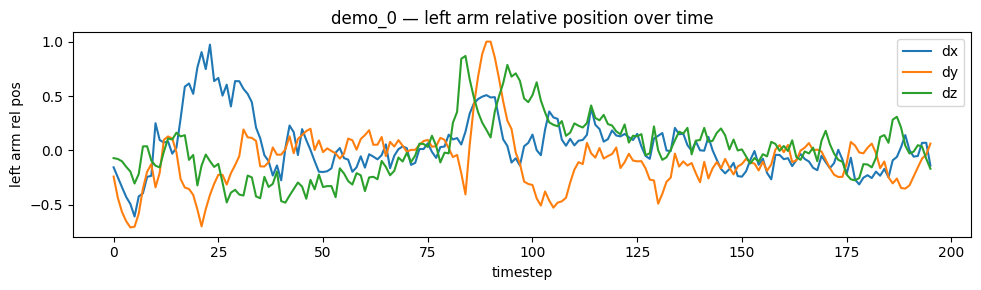

In [76]:
# 시간에 따른 action 궤적 (왼팔 상대위치 3차원)
left_pos = f[f'data/{demo}/action_dict/left_rel_pos'][:]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(left_pos[:, 0], label='dx')
ax.plot(left_pos[:, 1], label='dy')
ax.plot(left_pos[:, 2], label='dz')
ax.set_xlabel('timestep'); ax.set_ylabel('left arm rel pos')
ax.legend(); ax.set_title(f'{demo} — left arm relative position over time')
plt.tight_layout(); plt.show()

## 4. `obs` — 학습의 입력 (feature)

- 저차원 state (eef pos/quat, joint pos/vel, gripper qpos)
- 이미지 관측 (`agentview_image`, `robot*_eye_in_hand_image`) — 84x84 RGB

In [77]:
print('obs keys:')
for k in f[f'data/{demo}/obs'].keys():
    obj = f[f'data/{demo}/obs/{k}']
    print(f'  {k:35s} shape={obj.shape}  dtype={obj.dtype}')

obs keys:
  agentview_image                     shape=(196, 84, 84, 3)  dtype=uint8
  robot0_eef_pos                      shape=(196, 3)  dtype=float64
  robot0_eef_quat                     shape=(196, 4)  dtype=float64
  robot0_eef_quat_site                shape=(196, 4)  dtype=float32
  robot0_eye_in_hand_image            shape=(196, 84, 84, 3)  dtype=uint8
  robot0_gripper_qpos                 shape=(196, 2)  dtype=float64
  robot0_gripper_qvel                 shape=(196, 2)  dtype=float64
  robot0_joint_pos                    shape=(196, 7)  dtype=float64
  robot0_joint_pos_cos                shape=(196, 7)  dtype=float64
  robot0_joint_pos_sin                shape=(196, 7)  dtype=float64
  robot0_joint_vel                    shape=(196, 7)  dtype=float64
  robot1_eef_pos                      shape=(196, 3)  dtype=float64
  robot1_eef_quat                     shape=(196, 4)  dtype=float64
  robot1_eef_quat_site                shape=(196, 4)  dtype=float32
  robot1_eye_in_hand_image

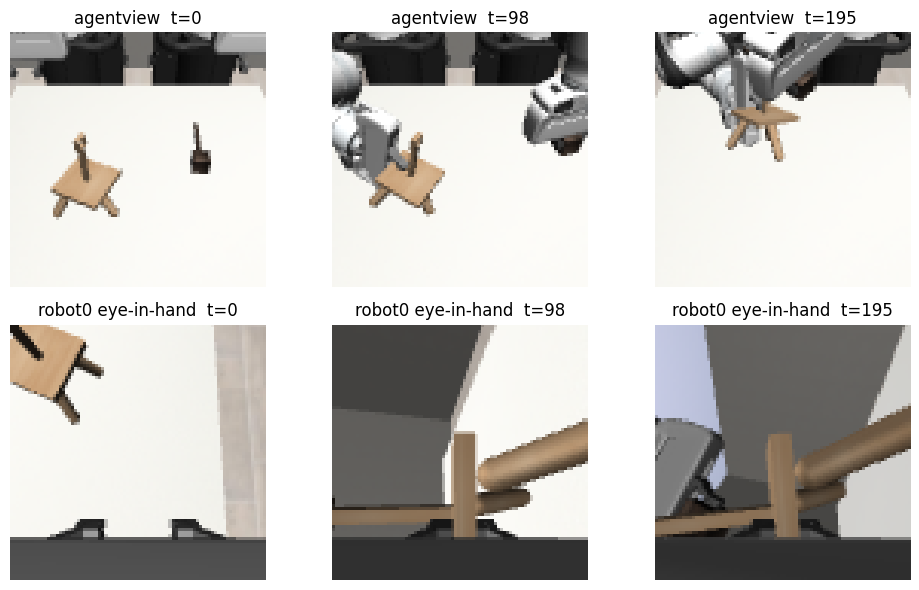

In [78]:
# 한 frame씩 시각화 — 시작/중간/끝
T = f[f'data/{demo}/obs/agentview_image'].shape[0]
ts = [0, T // 2, T - 1]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for col, t in enumerate(ts):
    axes[0, col].imshow(f[f'data/{demo}/obs/agentview_image'][t])
    axes[0, col].set_title(f'agentview  t={t}')
    axes[0, col].axis('off')
    axes[1, col].imshow(f[f'data/{demo}/obs/robot0_eye_in_hand_image'][t])
    axes[1, col].set_title(f'robot0 eye-in-hand  t={t}')
    axes[1, col].axis('off')
plt.tight_layout(); plt.show()

## 5. `datagen_info` — DexMimicGen 증강 알고리즘용 메타데이터

학습엔 직접 안 쓰임. 새 시연 생성 시 물체 포즈/서브태스크 분할 정보로 활용.

In [79]:
f[f'data/{demo}/datagen_info'].visititems(print_tree)

DSET   eef_pose  shape=(196, 2, 4, 4)  dtype=float64
DSET   gripper_action  shape=(196, 2, 1)  dtype=float64
GROUP  object_poses/
DSET   object_poses/needle  shape=(196, 4, 4)  dtype=float64
DSET   object_poses/tripod  shape=(196, 4, 4)  dtype=float64
GROUP  subtask_term_signals/
DSET   subtask_term_signals/grasp_needle  shape=(196,)  dtype=int64
DSET   subtask_term_signals/grasp_tripod  shape=(196,)  dtype=int64
DSET   target_pose  shape=(196, 2, 4, 4)  dtype=float64


## 6. demo 길이 분포 (T가 시연마다 다름)

min=181  max=276  mean=213.5  median=202


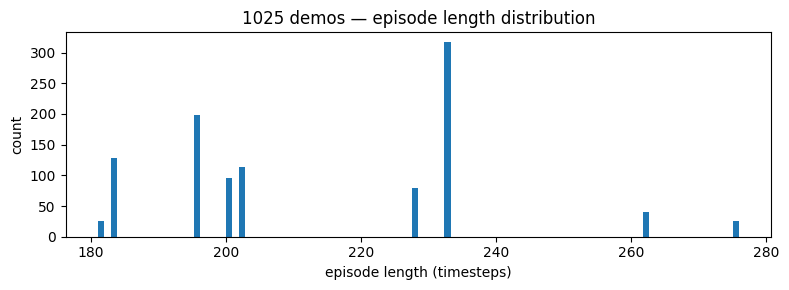

In [80]:
lengths = np.array([f[f'data/{d}/actions'].shape[0] for d in demos])
print(f'min={lengths.min()}  max={lengths.max()}  mean={lengths.mean():.1f}  median={np.median(lengths):.0f}')

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=100)
plt.xlabel('episode length (timesteps)'); plt.ylabel('count')
plt.title(f'{len(demos)} demos — episode length distribution')
plt.tight_layout(); plt.show()

## 7. lazy-load 팁

HDF5는 슬라이싱한 부분만 메모리에 올라감 — 4GB 파일이라도 한 frame만 읽으면 빠름.

single frame size: 21168 bytes
stacked 8 first-frames: (8, 84, 84, 3)


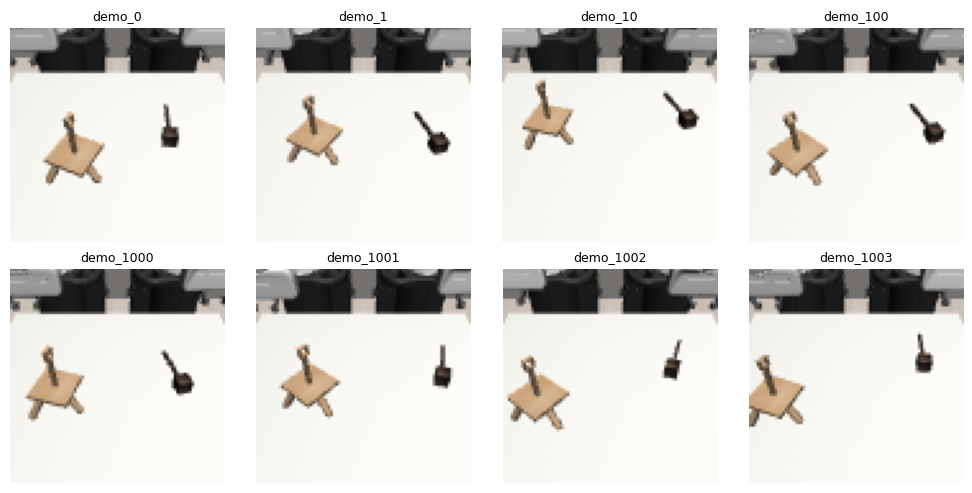

In [81]:
# 전체 로딩하지 않고 50번째 프레임만
img50 = f[f'data/{demo}/obs/agentview_image'][50]   # (84, 84, 3) uint8
print('single frame size:', img50.nbytes, 'bytes')

# 여러 demo의 첫 프레임만 모아 보기 (전체 로딩 X)
first_frames = np.stack([f[f'data/{d}/obs/agentview_image'][0] for d in demos[:8]])
print('stacked 8 first-frames:', first_frames.shape)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, d in zip(axes.flat, first_frames, demos[:8]):
    ax.imshow(img); ax.set_title(d, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

In [82]:
f.close()